In [17]:
!pip install mediapipe==0.10.35

In [18]:
import cv2
import numpy as np

def merge_videos(video1_path, video2_path, output_path):
    cap1 = cv2.VideoCapture(video1_path)
    cap2 = cv2.VideoCapture(video2_path)

    fps1 = cap1.get(cv2.CAP_PROP_FPS) or 30
    fps2 = cap2.get(cv2.CAP_PROP_FPS) or 30
    w1, h1 = int(cap1.get(cv2.CAP_PROP_FRAME_WIDTH)),  int(cap1.get(cv2.CAP_PROP_FRAME_HEIGHT))
    w2, h2 = int(cap2.get(cv2.CAP_PROP_FRAME_WIDTH)),  int(cap2.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fps = fps1
    target_height = min(h1, h2, 720)
    new_w1 = int(w1 * (target_height / h1))
    new_w2 = int(w2 * (target_height / h2))
    out_w  = max(new_w1, new_w2)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (out_w, target_height))

    total_v1 = 0
    total_v2 = 0

    while cap1.isOpened():
        ret, frame = cap1.read()
        if not ret: break
        resized = cv2.resize(frame, (new_w1, target_height))
        if new_w1 < out_w:
            pad = np.zeros((target_height, out_w - new_w1, 3), dtype=np.uint8)
            resized = np.hstack([resized, pad])
        out.write(resized)
        total_v1 += 1

    while cap2.isOpened():
        ret, frame = cap2.read()
        if not ret: break
        resized = cv2.resize(frame, (new_w2, target_height))
        if new_w2 < out_w:
            pad = np.zeros((target_height, out_w - new_w2, 3), dtype=np.uint8)
            resized = np.hstack([resized, pad])
        out.write(resized)
        total_v2 += 1

    cap1.release()
    cap2.release()
    out.release()

    print(f" Merged successfully!")
    print(f"   Video 1 (Running):          {total_v1} frames")
    print(f"   Video 2 (Man Sitting):   {total_v2} frames")
    print(f"   Saved to: {output_path}")

    return total_v1, total_v2

#  Update paths
VIDEO1_PATH = '/content/Running.mp4'
VIDEO2_PATH = '/content/Sitting.mp4'
MERGED_PATH = '/content/merged_video.mp4'

frames_v1, frames_v2 = merge_videos(VIDEO1_PATH, VIDEO2_PATH, MERGED_PATH)
TRANSITION_FRAME = frames_v1
print(f"\n Running → Sitting transition at frame: {TRANSITION_FRAME}")

 Merged successfully!
   Video 1 (Running):          1010 frames
   Video 2 (Man Sitting):   526 frames
   Saved to: /content/merged_video.mp4

 Running → Sitting transition at frame: 1010


In [19]:
import mediapipe as mp
from collections import deque
import matplotlib.pyplot as plt

# Download model
!wget -q -O pose_landmarker.task -c \
https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task


BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode


options = PoseLandmarkerOptions(
    base_options=BaseOptions(
        model_asset_path='pose_landmarker.task'
    ),
    running_mode=VisionRunningMode.VIDEO,

    min_pose_detection_confidence=0.3,
    min_pose_presence_confidence=0.3,
    min_tracking_confidence=0.3,

    num_poses=1
)

landmarker = PoseLandmarker.create_from_options(
    options
)


POSE_CONNECTIONS = [
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
    (11, 23), (12, 24),
    (23, 24),
    (23, 25), (25, 27),
    (24, 26), (26, 28),
]


def draw_pose_landmarks(
    frame,
    landmarks,
    h,
    w,
    activity=None
):

    color_map = {
        'Running': (
            (0, 255, 255),
            (0, 165, 255)
        ),
        'Sitting': (
            (255, 0, 255),
            (255, 0, 0)
        )
    }

    joint_color, bone_color = color_map.get(
        activity,
        ((0, 255, 0),
         (255, 0, 0))
    )

    for lm in landmarks:
        cx = int(lm.x * w)
        cy = int(lm.y * h)

        cv2.circle(
            frame,
            (cx, cy),
            5,
            joint_color,
            -1
        )

    for s, e in POSE_CONNECTIONS:

        if s < len(landmarks) and e < len(landmarks):

            x1 = int(landmarks[s].x * w)
            y1 = int(landmarks[s].y * h)

            x2 = int(landmarks[e].x * w)
            y2 = int(landmarks[e].y * h)

            cv2.line(
                frame,
                (x1, y1),
                (x2, y2),
                bone_color,
                2
            )


def smooth_keypoints(
    history,
    new_points,
    window=5
):

    history.append(new_points)

    if len(history) > window:
        history.popleft()

    return np.mean(history, axis=0)


keypoints_history = deque()
all_keypoints = []
frames = []
raw_landmarks_list = []


cap = cv2.VideoCapture(MERGED_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)

if fps <= 0:
    fps = 30

frame_width = int(
    cap.get(cv2.CAP_PROP_FRAME_WIDTH)
)

frame_height = int(
    cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
)

print(
    f"Processing: "
    f"{frame_width}x{frame_height} "
    f"@ {fps:.1f} fps"
)


frame_count = 0

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    rgb_frame = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb_frame
    )

    timestamp_ms = int(
        frame_count / fps * 1000
    )

    detection_result = (
        landmarker.detect_for_video(
            mp_image,
            timestamp_ms
        )
    )

    annotated_frame = np.copy(frame)

    if (
        detection_result.pose_landmarks
        and len(
            detection_result.pose_landmarks
        ) > 0
    ):

        landmark_list = (
            detection_result
            .pose_landmarks[0]
        )

        keypoints_array = np.array([
            [lm.x, lm.y, lm.z]
            for lm in landmark_list
        ])

        smoothed = smooth_keypoints(
            keypoints_history,
            keypoints_array
        )

        all_keypoints.append(
            smoothed
        )

        raw_landmarks_list.append(
            landmark_list
        )

        draw_pose_landmarks(
            annotated_frame,
            landmark_list,
            frame_height,
            frame_width
        )

    else:
        all_keypoints.append(None)
        raw_landmarks_list.append(None)

    frames.append(annotated_frame)

    frame_count += 1


cap.release()
landmarker.close()


print(f"Total frames: {len(frames)}")
print(f"Pose detected: "f"{sum(1 for k in all_keypoints if k is not None)}")
print(f"No pose detected: "f"{sum(1 for k in all_keypoints if k is None)}")

Processing: 404x720 @ 30.0 fps
Total frames: 1536
Pose detected: 1482
No pose detected: 54


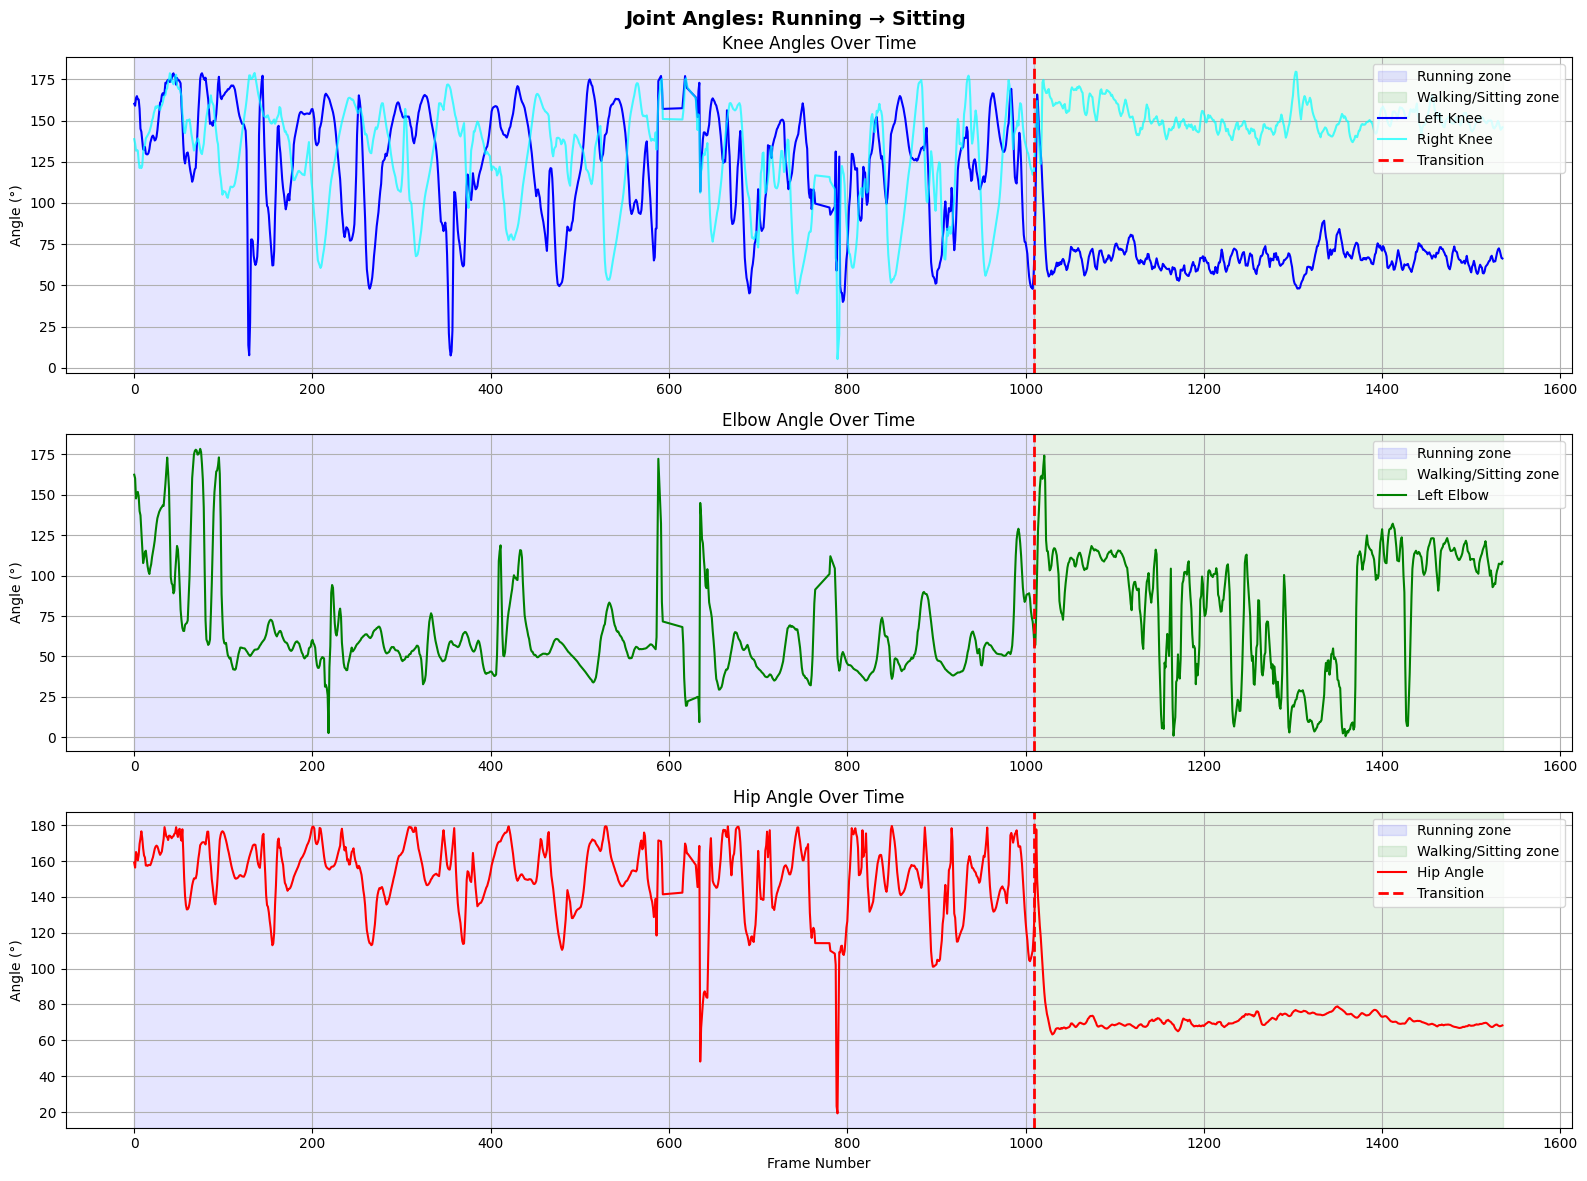


 Average Angles by Video Section:
Angle                (Running)            Man (Sit)
-------------------------------------------------------
Knee Left            124.9                67.0
Knee Right           125.6                151.4
Elbow                63.7                 82.2
Hip                  151.8                72.1


In [21]:
# TASK 2: Joint Angle Computation

LANDMARKS = {
    'left_shoulder': 11,  'right_shoulder': 12,
    'left_elbow':    13,  'right_elbow':    14,
    'left_wrist':    15,  'right_wrist':    16,
    'left_hip':      23,  'right_hip':      24,
    'left_knee':     25,  'right_knee':     26,
    'left_ankle':    27,  'right_ankle':    28
}

def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba, bc  = a - b, c - b
    cosine  = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))

knee_angles       = []
knee_right_angles = []
elbow_angles      = []
hip_angles        = []

for kp in all_keypoints:
    if kp is None:
        knee_angles.append(None)
        knee_right_angles.append(None)
        elbow_angles.append(None)
        hip_angles.append(None)
        continue

    knee_L = calculate_angle(
        kp[LANDMARKS['left_hip']][:2],
        kp[LANDMARKS['left_knee']][:2],
        kp[LANDMARKS['left_ankle']][:2]
    )
    knee_R = calculate_angle(
        kp[LANDMARKS['right_hip']][:2],
        kp[LANDMARKS['right_knee']][:2],
        kp[LANDMARKS['right_ankle']][:2]
    )
    elbow = calculate_angle(
        kp[LANDMARKS['left_shoulder']][:2],
        kp[LANDMARKS['left_elbow']][:2],
        kp[LANDMARKS['left_wrist']][:2]
    )
    hip = calculate_angle(
        kp[LANDMARKS['left_shoulder']][:2],
        kp[LANDMARKS['left_hip']][:2],
        kp[LANDMARKS['left_knee']][:2]
    )

    knee_angles.append(knee_L)
    knee_right_angles.append(knee_R)
    elbow_angles.append(elbow)
    hip_angles.append(hip)

# Filter valid
valid_idx    = [i for i, k in enumerate(knee_angles) if k is not None]
knee_valid   = [knee_angles[i]       for i in valid_idx]
knee_R_valid = [knee_right_angles[i] for i in valid_idx]
elbow_valid  = [elbow_angles[i]      for i in valid_idx]
hip_valid    = [hip_angles[i]        for i in valid_idx]

# ── Plot ──
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Shade regions by activity
def shade_region(ax, start, end, color, label):
    ax.axvspan(start, end, alpha=0.1, color=color, label=label)

for ax in axes:
    shade_region(ax, 0,                TRANSITION_FRAME,              'blue',   'Running zone')
    shade_region(ax, TRANSITION_FRAME, TRANSITION_FRAME + frames_v2,  'green',  'Walking/Sitting zone')

axes[0].plot(valid_idx, knee_valid,   color='blue', label='Left Knee',  linewidth=1.5)
axes[0].plot(valid_idx, knee_R_valid, color='cyan', label='Right Knee', linewidth=1.5, alpha=0.7)
axes[0].axvline(x=TRANSITION_FRAME, color='red', linestyle='--', linewidth=2, label='Transition')
axes[0].set_ylabel('Angle (°)')
axes[0].set_title('Knee Angles Over Time')
axes[0].legend(loc='upper right')
axes[0].grid(True)

axes[1].plot(valid_idx, elbow_valid, color='green', label='Left Elbow', linewidth=1.5)
axes[1].axvline(x=TRANSITION_FRAME, color='red', linestyle='--', linewidth=2)
axes[1].set_ylabel('Angle (°)')
axes[1].set_title('Elbow Angle Over Time')
axes[1].legend(loc='upper right')
axes[1].grid(True)

axes[2].plot(valid_idx, hip_valid, color='red', label='Hip Angle', linewidth=1.5)
axes[2].axvline(x=TRANSITION_FRAME, color='red', linestyle='--', linewidth=2, label='Transition')
axes[2].set_xlabel('Frame Number')
axes[2].set_ylabel('Angle (°)')
axes[2].set_title('Hip Angle Over Time')
axes[2].legend(loc='upper right')
axes[2].grid(True)

plt.suptitle('Joint Angles: Running → Sitting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('joint_angles.png', dpi=150)
plt.show()

# Print average angles per zone
bolt_idx    = [i for i in valid_idx if i < TRANSITION_FRAME]
man_idx     = [i for i in valid_idx if i >= TRANSITION_FRAME]

print("\n Average Angles by Video Section:")
print(f"{'Angle':<20} {'(Running)':<20} {'Man (Sit)'}")
print("-" * 55)
for name, angles in [('Knee Left', knee_angles), ('Knee Right', knee_right_angles),
                      ('Elbow', elbow_angles), ('Hip', hip_angles)]:
    b_avg = np.mean([angles[i] for i in bolt_idx if angles[i] is not None])
    m_avg = np.mean([angles[i] for i in man_idx  if angles[i] is not None])
    print(f"{name:<20} {b_avg:<20.1f} {m_avg:.1f}")

In [22]:
# TASK 3: Rule-Based Classification
# Activities: Running, Sitting

def classify_activity(
    knee_L,
    knee_R,
    hip,
    elbow
):

    if any(
        v is None
        for v in [
            knee_L,
            knee_R,
            hip,
            elbow
        ]
    ):
        return 'Unknown'

    knee_avg = (
        knee_L + knee_R
    ) / 2

    knee_diff = abs(
        knee_L - knee_R
    )

    # Sitting
    if knee_avg < 125 and hip < 130:
        return 'Sitting'

    # Running
    if knee_diff > 20 and hip > 140:
        return 'Running'

    return 'Unknown'


predicted_labels = []

for i in range(
    len(knee_angles)
):

    label = classify_activity(
        knee_angles[i],
        knee_right_angles[i],
        hip_angles[i],
        elbow_angles[i]
    )

    predicted_labels.append(
        label
    )


ground_truth = []

for i in range(
    len(predicted_labels)
):

    if i < TRANSITION_FRAME:ground_truth.append('Running')
    else:
        ground_truth.append('Sitting')


correct = sum(
    p == g
    for p, g in zip(
        predicted_labels,
        ground_truth
    )
    if p != 'Unknown'
)

valid_count = sum(
    1
    for p in predicted_labels
    if p != 'Unknown'
)

accuracy = (
    correct / valid_count * 100
    if valid_count > 0
    else 0
)

print(
    f"Overall Accuracy: "
    f"{accuracy:.2f}%"
)

Overall Accuracy: 90.45%


In [23]:
cap = cv2.VideoCapture(
    MERGED_PATH
)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter('/mnt/data/output_annotated.mp4',fourcc,fps,(frame_width,frame_height))


activity_colors = {
    'Running': (0, 255, 255),
    'Sitting': (255, 0, 255),
    'Unknown': (128, 128, 128)
    }


for i, frame in enumerate(frames):

    annotated = np.copy(frame)

    if i < len(predicted_labels):

        label = predicted_labels[i]

        color = activity_colors.get(
            label,
            (255, 255, 255)
        )

        if (
            i < len(
                raw_landmarks_list
            )
            and raw_landmarks_list[i]
            is not None
        ):

            draw_pose_landmarks(
                annotated,
                raw_landmarks_list[i],
                frame_height,
                frame_width,
                activity=label
            )

        cv2.putText(annotated,f'Activity: {label}',(30, 50),cv2.FONT_HERSHEY_SIMPLEX,1.2,color,3)

        cv2.putText(annotated,f'Frame: {i}',(30, 95),cv2.FONT_HERSHEY_SIMPLEX, 0.7,(255, 255, 255),2)

    out.write(annotated)

out.release()

print(
    "Annotated video saved!"
)

Annotated video saved!
